In [1]:
import utils_FaIR_JAX
import utils_inverse
import matplotlib.pyplot as plt
import jax

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for CO<sub>2</sub>

## 1. Verify emulator framework and generate baseline emulator

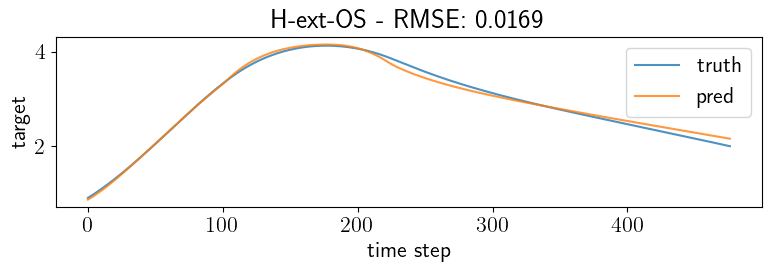

||grad BC||: 0.0
||grad CH4||: 0.0
||grad CO2||: 6.406606553355232e-05
||grad N2O||: 0.0
||grad Sulfur||: 0.0


In [2]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents, mode='MESM')
emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents, mode='MESM')

train_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX, mode='MESM')
test_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_test_JAX, mode='MESM')
train_s, test_s, stats = utils_inverse.split_and_scale(train_data, test_data)

idx_demo = 1
params0 = utils_inverse.create_baseline(train_s, test_s, idx_demo, verbose=False)

test_scen = 'historical'
utils_inverse.test_get_grad(test_scen, params0, emis_dict_train_JAX, train_data, test_data, active=("CO2"), mode='MESM')

## 2. Optimize CO<sub>2</sub> emissions time series used in training

### 2a. Train baseline emulator on ScenarioMIP tier 1

In [3]:
emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True)
emis_dict_all_JAX = emis_dict_tier1_JAX | emis_dict_tier2_JAX | emis_dict_DECK_JAX | emis_dict_CS3_JAX
test_sets = {
    "Tier 1": emis_dict_tier1_JAX,
    "Tier 2": emis_dict_tier2_JAX,
    "DECK": emis_dict_DECK_JAX,
    "CS3": emis_dict_CS3_JAX,
    "All": emis_dict_all_JAX
}

In [4]:
paramsK_base, baseline_results, baseline_preds, ground_truth = utils_inverse.evaluate_baseline_over_multiple_tests(
    emis_dict_train=emis_dict_tier1_JAX,
    test_sets=test_sets,
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden_sizes=[16],
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

import pickle
path = 'checkpoints/co2/baseline_co2_only_MESM.pkl'

with open(path, "wb") as f:
    pickle.dump(baseline_results, f)

for test_set in baseline_results:
    per_scen = baseline_results[test_set]
    mean_err = baseline_results[test_set]['mean']
    print(f"\n{test_set} mean NRMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean NRMSE: 0.0510
  historical                      0.1245
  H-ext                           0.0074
  M                               0.0235
  ML                              0.0275
  L                               0.0383
  VLLO-ext                        0.0837
  VLHO                            0.0523

Tier 2 mean NRMSE: 0.1239
  historical                      0.1245
  H-ext-OS                        0.0357
  M-ext                           0.1302
  ML-ext                          0.0966
  L-ext                           0.1866
  VLHO-ext                        0.1694

DECK mean NRMSE: 0.0474
  abrupt-4xCO2                    0.0480
  1pctCO2                         0.0468

CS3 mean NRMSE: 0.0949
  AA                              0.0631
  CT                              0.0256
  historical                      0.1960

All mean NRMSE: 0.0905
  historical                      0.1960
  H-ext                           0.0052
  M                               0.0215
  ML        

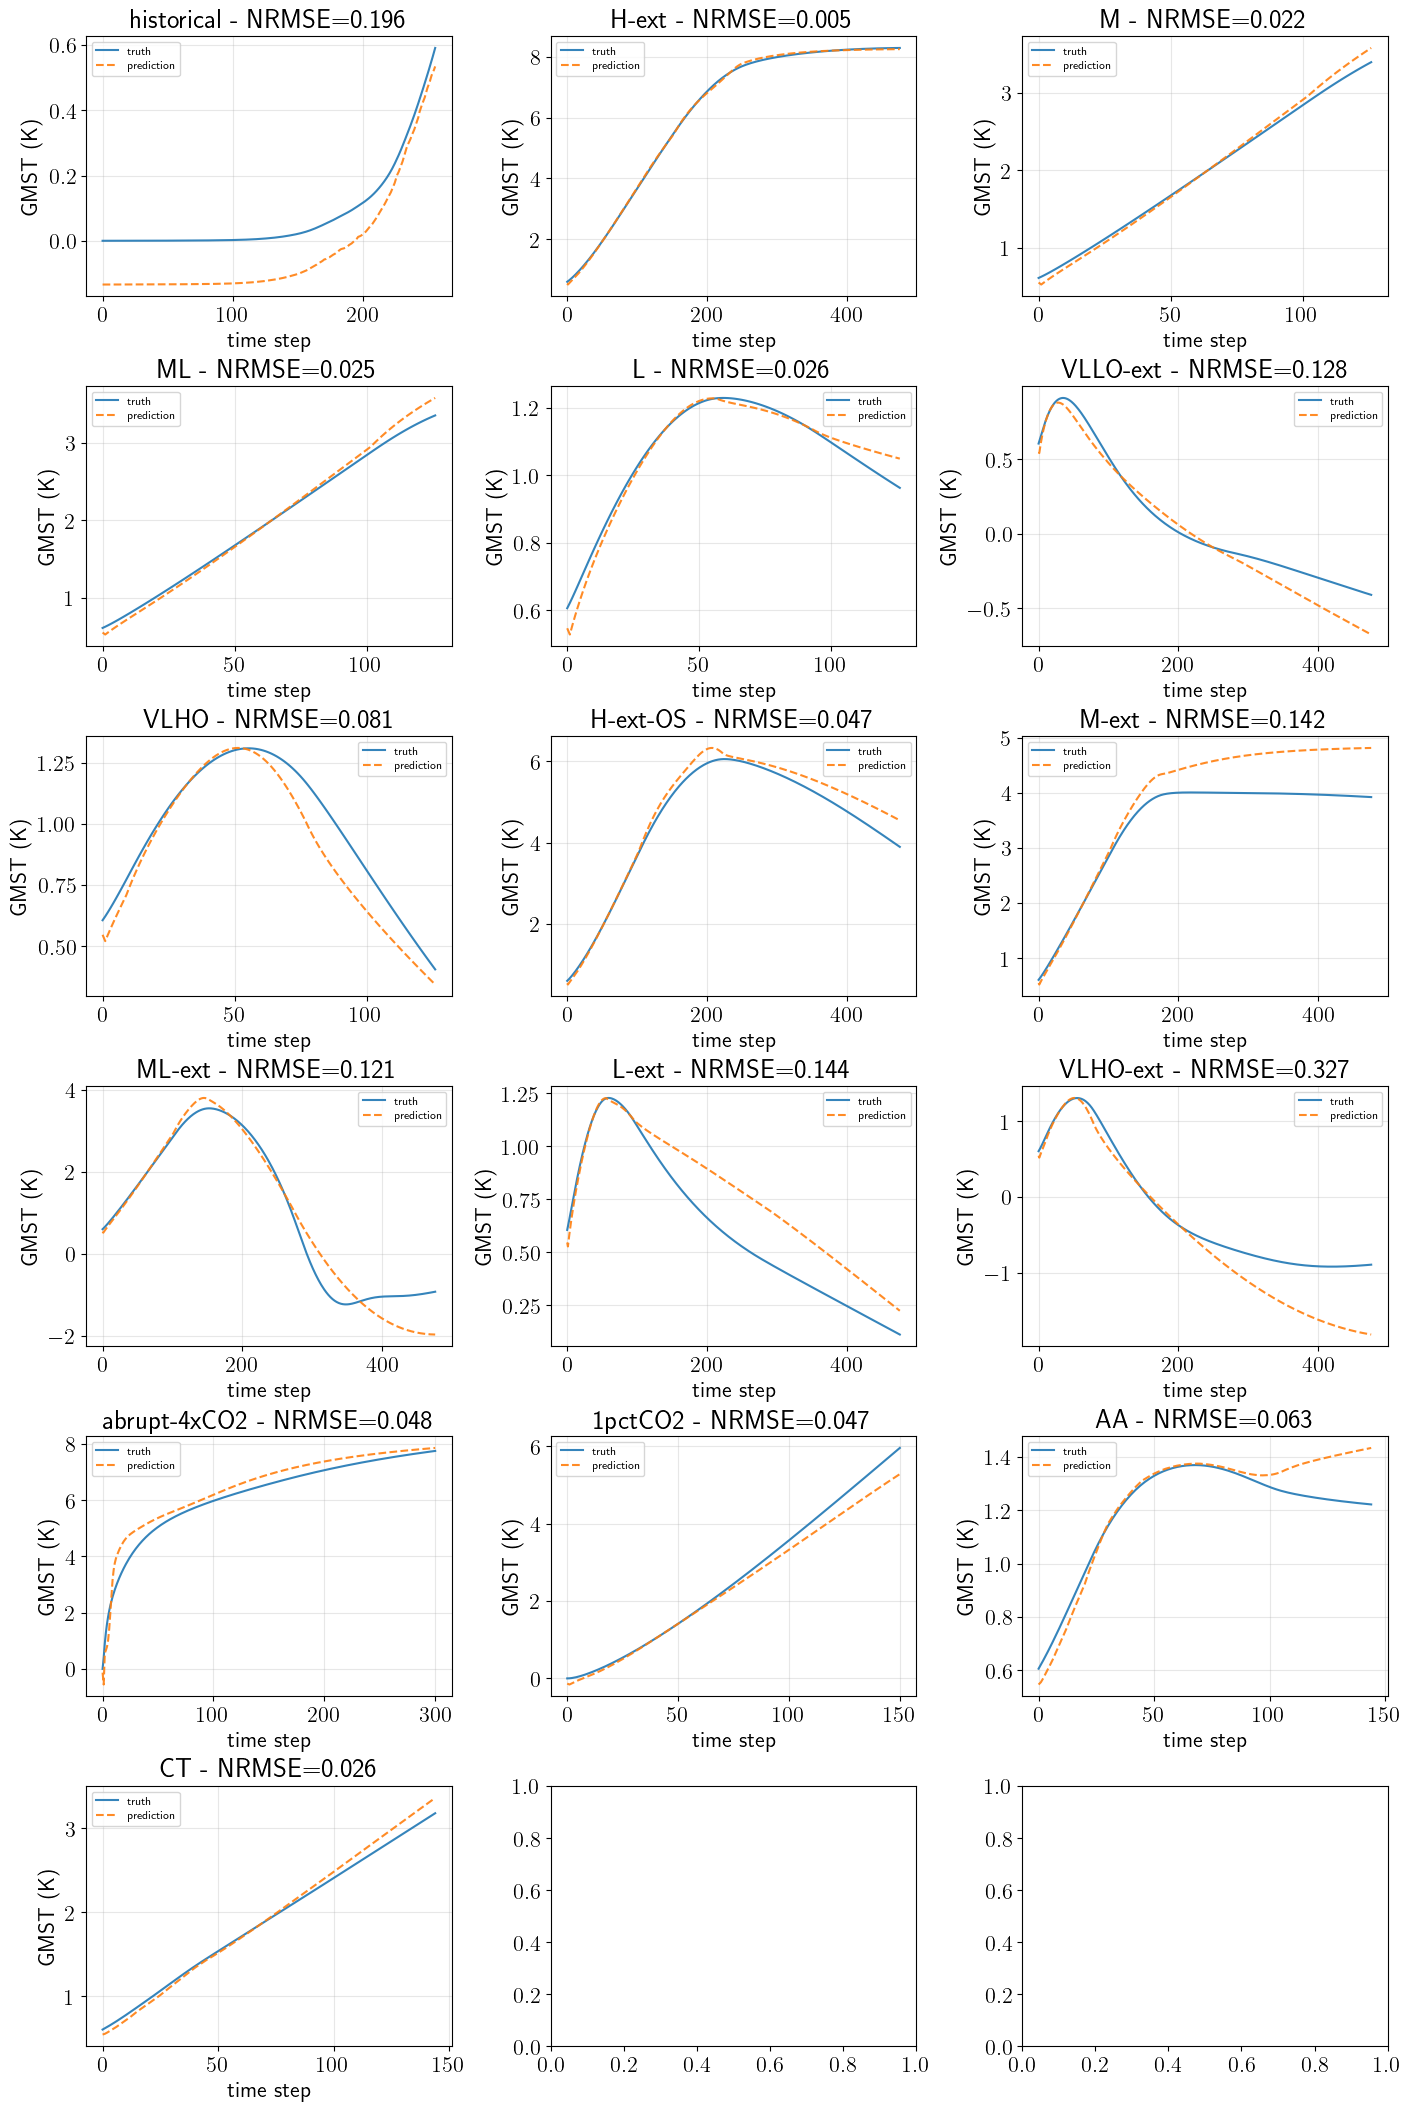

In [5]:
import numpy as np
test_set = 'All'
N_scens = len(baseline_results[test_set])
rows = int(np.ceil(N_scens / 3))
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5*rows), constrained_layout=True)
axes = axes.ravel()

for i, scen in enumerate(baseline_results[test_set]):
    if scen == 'mean':
        continue
    ax = axes[i]
    ax.plot(ground_truth[test_set][scen],  label="truth", alpha=0.9)
    ax.plot(baseline_preds[test_set][scen],  label="prediction", ls="--", alpha=0.9)
    ax.set_title(f"{scen} - NRMSE={baseline_results[test_set][scen]:.3f}")
    ax.set_xlabel("time step")
    ax.set_ylabel("GMST (K)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

### 2b. Optimize for individual scenarios, starting from constant initial condition

In [10]:
emis_dict_valid = {}
emis_dict_valid['H-ext'] = emis_dict_train_JAX['H-ext'].copy()
emis_dict_valid['historical'] = emis_dict_train_JAX['historical'].copy()

IC = 'constant'

results_CO2_trivial_const = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=1000,
    step_size=1e4,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/co2/inverse_H-ext_{IC}_co2_only_MESM.pkl",
    checkpoint_every=50,
    resume_if_exists=False,
    preds_every=50,
    active_agents=("CO2",),
    init_spec=IC,
    inactive_mode="zeros",
    T=477,
    filter_hist=True,
)

Starting fresh...


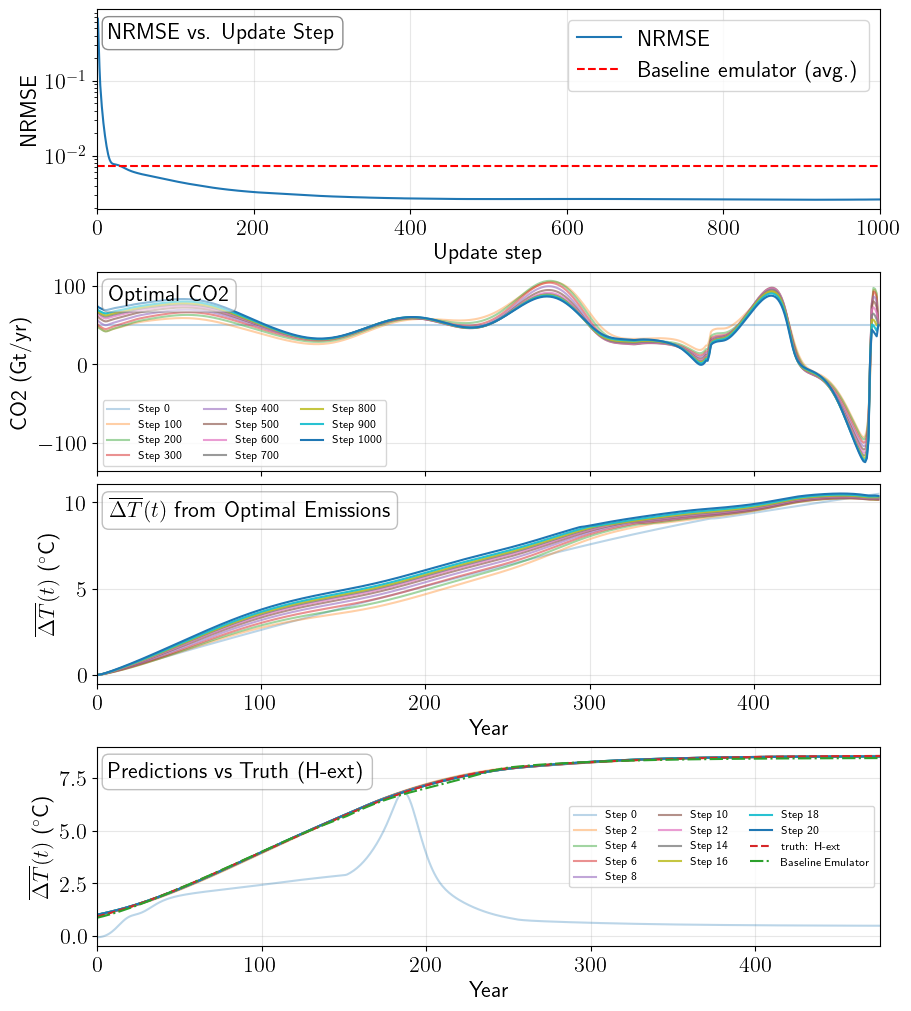

In [11]:
predict_plot = 'H-ext'
utils_inverse.plot_inverse_results(
    results_CO2_trivial_const,
    baseline_results['Tier 1'][predict_plot],
    active_agents=('CO2',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

### 2c. Optimize training data for predictive skill over all scenario configurations, beginning from constant IC

In [29]:
emis_dicts_valid = [(emis_dict_tier1_JAX.copy(), 'tier1'),
                    (emis_dict_tier2_JAX.copy(), 'tier2'),
                    (emis_dict_DECK_JAX.copy(), 'DECK'),
                    (emis_dict_CS3_JAX.copy(), 'CS3'),
                    (emis_dict_all_JAX.copy(), 'all')]
IC = 'constant'

groups = ['CS3']

#for emis_dict, group in emis_dicts_valid:
for group in groups:
    print(f'Optimizing over {group}')
    results_CO2_constant = utils_inverse.optimize_emissions_inverse(
        emis_dict=emis_dict,
        params0=params0,
        num_updates=1000,
        step_size=1e3,
        momentum=0.9,
        nesterov=True,
        K_inner=400,
        lr_inner=5e-2,
        wd_inner=1e-2,
        checkpoint_path=f"checkpoints/co2/inverse_{IC}_{group}_co2_only_MESM.pkl",
        checkpoint_every=50,
        resume_if_exists=True,
        preds_every=50,
        active_agents=("CO2",),
        init_spec=IC,
        inactive_mode="zeros",
        T=751,
        n_nonneg_prefix=0,
        #smoothness_weight=1e-5
    )

Optimizing over CS3
Resuming from checkpoint...


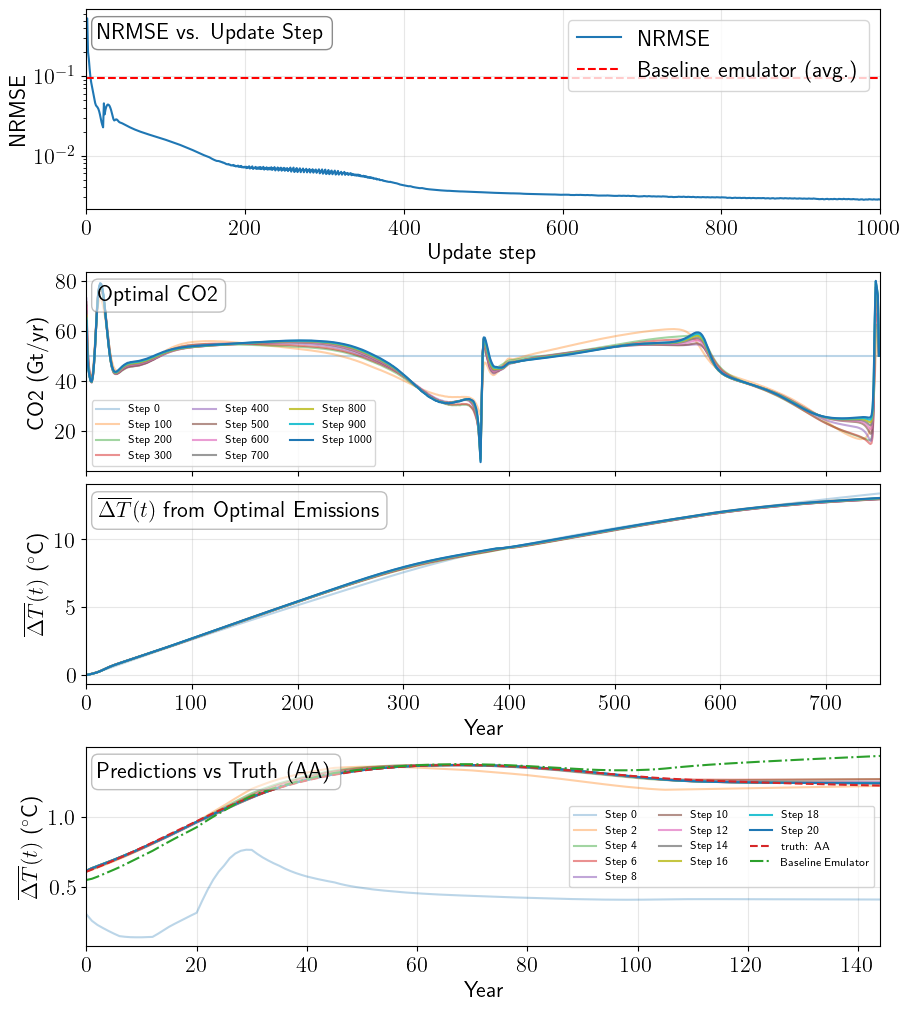

In [30]:
predict_plot = 'AA'
baseline_test = 'CS3'
utils_inverse.plot_inverse_results(
    results_CO2_constant,
    baseline_results[baseline_test]['mean'],
    active_agents=('CO2',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds[baseline_test][predict_plot]
)